### (a) Download e Parse do Ficheiro FASTA
**Contexto:** O formato FASTA é o padrão para armazenar sequências biológicas. Esta etapa é responsável por ler o ficheiro `influenza_dataset.fasta`, extrair o *accession number* de cada cabeçalho e armazenar a sequência completa de nucleótidos num dicionário, convertendo tudo para letras maiúsculas e removendo quebras de linha.

In [21]:
def parse_fasta(filepath: str) -> dict:
    """
    Lê um ficheiro FASTA e retorna um dicionário mapeando accession para a sequência completa.
    """
    sequences = {}
    current_accession = ""
    
    with open(filepath, 'r') as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                current_accession = line[1:].split()[0]
                sequences[current_accession] = ""
            else:
                if current_accession:
                    sequences[current_accession] += line.upper()
                    
    return sequences

In [22]:
# Célula de Teste da Tarefa (a)
arquivo_fasta = 'influenza_dataset.fasta'
sequences_d2 = parse_fasta(arquivo_fasta)

print("Accessions carregados com sucesso:")
print(list(sequences_d2.keys()))

Accessions carregados com sucesso:
['NC_026431.1', 'NC_007373.1', 'CY121659.1', 'CY018104.1', 'CY006241.1']


### (b) Descrição e Tamanho das Sequências
**Contexto:** Conhecer o tamanho de cada sequência é o primeiro passo para qualquer análise comparativa. Para o Influenza (D2), as sequências podem ter tamanhos muito diferentes, pois representam diferentes segmentos genómicos. Além do tamanho, iremos apresentar uma tabela com metadados (Organismo, Ano, País/Origem, Segmento) extraídos do GenBank.3

In [23]:
def sequence_length(sequences: dict) -> dict:
    """
    Calcula o tamanho (em bp) de cada sequência no dicionário.
    
    Parâmetros:
    sequences: dict - o dicionário retornado por parse_fasta()
    
    Retorno:
    dict - {accession_id: str, length: int}
    """
    return {accession: len(seq) for accession, seq in sequences.items()}

In [24]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd

# Célula de Teste da Tarefa (b)
lengths = sequence_length(sequences_d2)

# Criar uma lista com os metadados extraídos dos cabeçalhos do GenBank
# (Informações baseadas no ficheiro FASTA descarregado)
data = [
    {'Accession': 'NC_026431.1', 'Organismo': 'Influenza A (H1N1)', 'Ano': 2009, 'País/Origem': 'California', 'Segmento': 'Seg. 7 (M1/M2)', 'Tamanho (bp)': lengths['NC_026431.1']},
    {'Accession': 'NC_007373.1', 'Organismo': 'Influenza A (H3N2)', 'Ano': 2004, 'País/Origem': 'New York', 'Segmento': 'Seg. 1 (PB2)', 'Tamanho (bp)': lengths['NC_007373.1']},
    {'Accession': 'CY121659.1',  'Organismo': 'Influenza A (H1N1)', 'Ano': 2008, 'País/Origem': 'Hong Kong/reassortant', 'Segmento': 'Seg. 5 (NP)', 'Tamanho (bp)': lengths['CY121659.1']},
    {'Accession': 'CY018104.1',  'Organismo': 'Influenza B',        'Ano': 2000, 'País/Origem': 'Houston', 'Segmento': 'Seg. 5 (NP)', 'Tamanho (bp)': lengths['CY018104.1']},
    {'Accession': 'CY006241.1',  'Organismo': 'Influenza A (H3N2)', 'Ano': 1997, 'País/Origem': 'New York', 'Segmento': 'Seg. 2 (PB1)', 'Tamanho (bp)': lengths['CY006241.1']}
]

# Converter para DataFrame para apresentação em tabela
df_metadata = pd.DataFrame(data)

print("Tabela de Metadados e Tamanhos:")
display(df_metadata) # display() mostra uma tabela bem formatada no Jupyter

Tabela de Metadados e Tamanhos:


,Accession,Organismo,Ano,País/Origem,Segmento,Tamanho (bp)
0,NC_026431.1,Influenza A (H1N1),2009,California,Seg. 7 (M1/M2),982
1,NC_007373.1,Influenza A (H3N2),2004,New York,Seg. 1 (PB2),2341
2,CY121659.1,Influenza A (H1N1),2008,Hong Kong/reassortant,Seg. 5 (NP),1540
3,CY018104.1,Influenza B,2000,Houston,Seg. 5 (NP),1803
4,CY006241.1,Influenza A (H3N2),1997,New York,Seg. 2 (PB1),2309


### (c) Frequência de Nucleotídeos e Visualização
**Contexto:** A composição nucleotídica varia entre vírus, refletindo diferentes pressões evolutivas e adaptações ao hospedeiro. Esta etapa calcula a contagem e o percentual das bases (A, C, G, T) na sequência e gera gráficos comparativos de barras, onde A=azul, C=laranja, G=verde e T=vermelho.

In [26]:
import matplotlib.pyplot as plt

def nucleotide_frequency(sequence: str) -> dict:
    """
    Calcula a contagem e o percentual de A, C, G, T numa sequência.
    Retorna um dicionário com o formato: {'Base': (contagem, percentagem)}
    """
    total_len = len(sequence)
    if total_len == 0:
        return {'A': (0, 0.0), 'C': (0, 0.0), 'G': (0, 0.0), 'T': (0, 0.0)}
    
    counts = {'A': sequence.count('A'), 'C': sequence.count('C'), 
              'G': sequence.count('G'), 'T': sequence.count('T')}
            
    freqs = {nuc: (count, (count / total_len) * 100) for nuc, count in counts.items()}
    return freqs

def plot_nucleotide_frequency(accession: str, freqs: dict):
    """Gera um gráfico de barras com as frequências percentuais em ordem alfabética."""
    bases = ['A', 'C', 'G', 'T']
    percentages = [freqs[b][1] for b in bases]
    
    # Cores exigidas no guião: A=azul, T=vermelho, G=verde, C=laranja
    # Como a ordem alfabética é A, C, G, T, a ordem das cores será:
    colors = ['blue', 'orange', 'green', 'red'] 
    
    plt.figure(figsize=(6, 4))
    bars = plt.bar(bases, percentages, color=colors)
    plt.title(f'Frequência de Nucleotídeos - {accession}')
    plt.ylabel('Percentual (%)')
    plt.xlabel('Base Nitrogenada')
    
    # Exibe o valor em percentagem sobre cada barra
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', va='bottom')
        
    plt.ylim(0, max(percentages) + 15) # Dá um espaço extra no topo do gráfico
    plt.show()

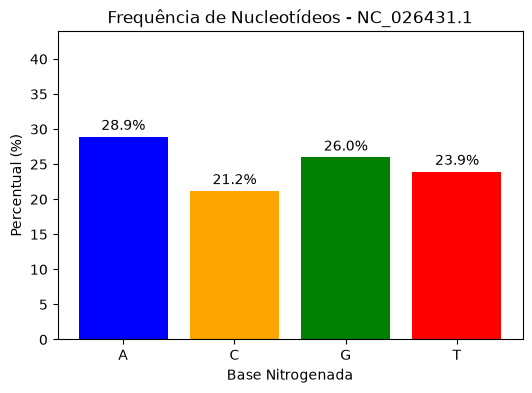

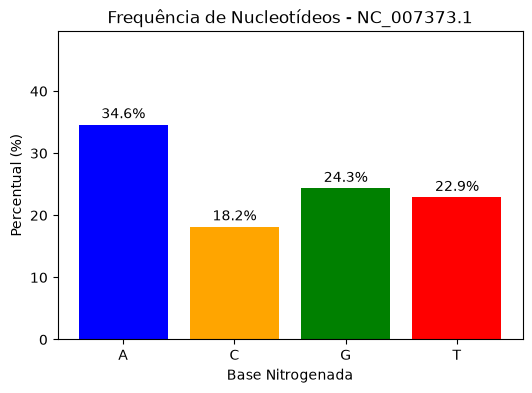

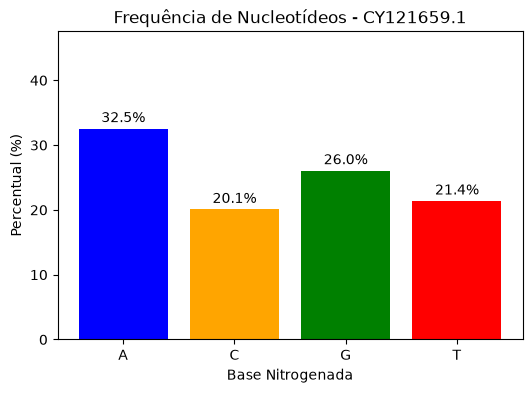

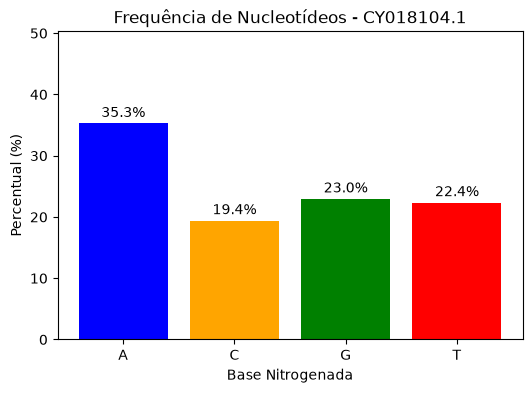

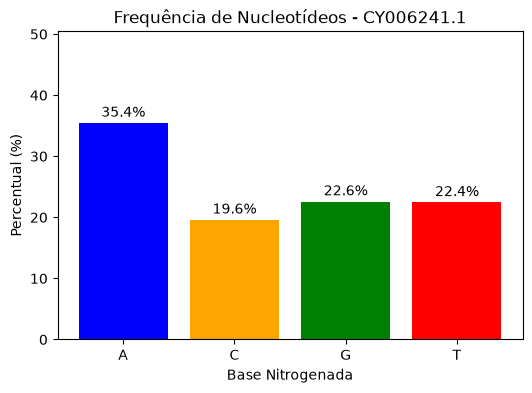

In [27]:
# Célula de Teste da Tarefa (c)
for accession, seq in sequences_d2.items():
    freqs = nucleotide_frequency(seq)
    plot_nucleotide_frequency(accession, freqs)

**Discussão Biológica:** *Espaço para o grupo preencher:* Observando os gráficos gerados, notamos que as frequências... (Aqui deverão descrever se há diferenças nas frequências entre as sequências e qual a explicação biológica - subtipos, origem geográfica, pressão evolutiva, etc).

### (d) Conteúdo GC e Temperatura de Melting (Tm)
**Contexto:** O conteúdo GC reflete a estabilidade do DNA. A Temperatura de Melting (Tm) é a temperatura em que 50% do DNA duplex está desnaturado, sendo um parâmetro essencial para o design de primers de PCR no diagnóstico viral.

**Justificativa da Fórmula e Importância no PCR:** Para este dataset (Influenza A), utilizamos a fórmula **GC simplificada** ($Tm = 81.5 + 0.41 \times GC\%$). Essa escolha justifica-se pelo fato de as sequências terem um tamanho médio de ~1.700 bp. A fórmula de Wallace é indicada apenas para primers curtos (< 14 nt) e superestimaria a temperatura nestes casos. O cálculo da Tm é crítico no diagnóstico por PCR do Influenza, pois garante que a temperatura de anelamento no termociclador seja configurada corretamente, permitindo que o primer se ligue especificamente à região alvo do vírus, evitando falsos negativos ou amplificações inespecíficas.

In [28]:
def gc_content(sequence: str) -> float:
    """
    Calcula o percentual de G+C em uma sequência.
    """
    if not sequence: return 0.0
    g_count = sequence.count('G')
    c_count = sequence.count('C')
    return ((g_count + c_count) / len(sequence)) * 100

def melting_temperature(sequence: str, formula: str = 'gc') -> float:
    """
    Calcula a Tm usando a fórmula escolhida: 'gc' (sequências longas) ou 'wallace' (primers < 14 nt).
    """
    if formula == 'wallace':
        a_count = sequence.count('A')
        t_count = sequence.count('T')
        g_count = sequence.count('G')
        c_count = sequence.count('C')
        return float(2 * (a_count + t_count) + 4 * (g_count + c_count))
        
    elif formula == 'gc':
        gc_perc = gc_content(sequence)
        return 81.5 + 0.41 * gc_perc
    else:
        raise ValueError("Fórmula deve ser 'gc' ou 'wallace'")

In [29]:
# Célula de Teste da Tarefa (d)
gc_tm_data = []

for accession, seq in sequences_d2.items():
    gc_perc = gc_content(seq)
    tm_calc = melting_temperature(seq, formula='gc')
    
    gc_tm_data.append({
        'Accession': accession,
        'Tamanho (bp)': len(seq),
        'Conteúdo GC (%)': round(gc_perc, 2),
        'Tm (°C)': round(tm_calc, 2)
    })

df_gc_tm = pd.DataFrame(gc_tm_data)
display(df_gc_tm)

,Accession,Tamanho (bp),Conteúdo GC (%),Tm (°C)
0,NC_026431.1,982,47.15,100.83
1,NC_007373.1,2341,42.50,98.93
2,CY121659.1,1540,46.10,100.40
3,CY018104.1,1803,42.37,98.87
4,CY006241.1,2309,42.14,98.78


### (e) Alinhamento Global (Needleman-Wunsch)
**Contexto:** O algoritmo Needleman-Wunsch (1970) encontra o alinhamento global ótimo entre duas sequências por meio de programação dinâmica, alinhando-as de ponta a ponta. É ideal para comparar sequências homólogas. Nesta etapa, utilizaremos os primeiros 300 nucleotídeos de cada sequência para realizar o alinhamento de todos os pares possíveis, calculando o score, as sequências alinhadas e o percentual de identidade.

In [30]:
def needleman_wunsch(seq1: str, seq2: str, match=1, mismatch=-1, gap=-2) -> tuple:
    """Implementa o alinhamento global NW com programação dinâmica."""
    n, m = len(seq1), len(seq2)
    dp_matrix = [[0 for _ in range(m + 1)] for _ in range(n + 1)]
    
    # Preenche a primeira linha e coluna com os penalties de gap
    for i in range(n + 1):
        dp_matrix[i][0] = i * gap
    for j in range(m + 1):
        dp_matrix[0][j] = j * gap
        
    # Preenche o resto da matriz
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if seq1[i-1] == seq2[j-1]:
                score_diag = dp_matrix[i-1][j-1] + match
            else:
                score_diag = dp_matrix[i-1][j-1] + mismatch
                
            score_up = dp_matrix[i-1][j] + gap
            score_left = dp_matrix[i][j-1] + gap
            
            dp_matrix[i][j] = max(score_diag, score_up, score_left)
            
    score_final = dp_matrix[n][m]
    return dp_matrix, score_final

def nw_traceback(seq1: str, seq2: str, dp_matrix: list, match=1, mismatch=-1, gap=-2) -> tuple:
    """Recupera o alinhamento realizando traceback na matriz DP do NW."""
    align1, align2 = "", ""
    i, j = len(seq1), len(seq2)
    
    while i > 0 and j > 0:
        current_score = dp_matrix[i][j]
        diag_score = dp_matrix[i-1][j-1]
        
        # Verifica se o score atual veio da diagonal
        calc_diag = diag_score + match if seq1[i-1] == seq2[j-1] else diag_score + mismatch
            
        if current_score == calc_diag:
            align1 = seq1[i-1] + align1
            align2 = seq2[j-1] + align2
            i -= 1
            j -= 1
        elif current_score == dp_matrix[i-1][j] + gap:
            align1 = seq1[i-1] + align1
            align2 = "-" + align2
            i -= 1
        else:
            align1 = "-" + align1
            align2 = seq2[j-1] + align2
            j -= 1
            
    # Traça o restante até chegar a (0,0) caso uma sequência termine antes
    while i > 0:
        align1 = seq1[i-1] + align1
        align2 = "-" + align2
        i -= 1
    while j > 0:
        align1 = "-" + align1
        align2 = seq2[j-1] + align2
        j -= 1
        
    return align1, align2

In [31]:
from itertools import combinations

# Extrair os primeiros 300 nt de cada sequência
seqs_300 = {acc: seq[:300] for acc, seq in sequences_d2.items()}
accessions = list(seqs_300.keys())

# Gerar todas as combinações possíveis (10 pares no total)
pares = list(combinations(accessions, 2))

print("Resultados do Alinhamento Global (Needleman-Wunsch):\n")

for par in pares:
    acc1, acc2 = par
    seq1, seq2 = seqs_300[acc1], seqs_300[acc2]
    
    dp_matrix, score = needleman_wunsch(seq1, seq2)
    al1, al2 = nw_traceback(seq1, seq2, dp_matrix)
    
    # Cálculo da Identidade: (matches / tamanho do alinhamento) * 100
    matches = sum(1 for a, b in zip(al1, al2) if a == b and a != '-')
    identidade = (matches / len(al1)) * 100
    
    print(f"Par: {acc1} x {acc2}")
    print(f"Score: {score} | Identidade: {identidade:.2f}%")
    print(f"Seq1: {al1[:60]}")
    print(f"Seq2: {al2[:60]}")
    print("-" * 50)

Resultados do Alinhamento Global (Needleman-Wunsch):

Par: NC_026431.1 x NC_007373.1
Score: -52 | Identidade: 48.76%
Seq1: -----ATG-A-GTC--TTCTAACCGAG-GTCGAAACGTACGTTCTTTCTA-TCATCCCGT
Seq2: AGCAAAAGCAGGTCAATTATATTC-AGTATGGAAA-GAATAAAAGAACTACGGAACCTG-
--------------------------------------------------
Par: NC_026431.1 x CY121659.1
Score: -34 | Identidade: 50.31%
Seq1: AT-GAGTCT-TCTAACCGAGGTCGAAACGTACGTTCTTTC-TATCATCCCGTCAGGCCCC
Seq2: GTAGATAATCACTCACTGA-GT-GACATCAAAATCATGGCGTCTCAAGGCACCAAACGAT
--------------------------------------------------
Par: NC_026431.1 x CY018104.1
Score: -49 | Identidade: 48.28%
Seq1: ATGAGTCTTCTA--ACCGAGGTCGAAACGTACGTTCTTTCTATCAT-CCCGTCAGGCCCC
Seq2: GTGA-ACTTCAAGTACC-A-GT--AAAAGAACTGAAAATC-AAAATGTCCAACATG---G
--------------------------------------------------
Par: NC_026431.1 x CY006241.1
Score: -33 | Identidade: 50.78%
Seq1: ATGAGTCTTCTAACCGAGGTCGAAACGTAC-GTTCTTTCTATCATCCCGTCAG-GCCCCC
Seq2: CAAACCATTTGAATGGATGTC-AATCCGACTCTACTTTTCCTAAAGGTTTCAGCGCAAAA
--------

**Discussão Biológica:** *Espaço para o grupo preencher:* (Avaliar se há regiões altamente conservadas nos primeiros 300 nt entre as diferentes sequências de Influenza analisadas. Como elas pertencem a diferentes segmentos genômicos, qual é o impacto disso na identidade global reportada pelo Needleman-Wunsch?)

### (f) Alinhamento Local (Smith-Waterman)
**Contexto:** O algoritmo Smith-Waterman (1981) é uma variação do NW para alinhamento local. A sua diferença fundamental é que os valores na matriz de pontuação nunca ficam negativos (são substituídos por zero) e o *traceback* começa na célula com o score máximo, parando quando encontra um zero. Isso permite destacar domínios altamente conservados entre sequências que, globalmente, podem ser muito dissimilares.

In [32]:
def smith_waterman(seq1: str, seq2: str, match=1, mismatch=-1, gap=-2) -> tuple:
    """Implementa o alinhamento local SW."""
    n, m = len(seq1), len(seq2)
    dp_matrix = [[0 for _ in range(m + 1)] for _ in range(n + 1)]
    score_max = 0
    pos_max = (0, 0)
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if seq1[i-1] == seq2[j-1]:
                score_diag = dp_matrix[i-1][j-1] + match
            else:
                score_diag = dp_matrix[i-1][j-1] + mismatch
                
            score_up = dp_matrix[i-1][j] + gap
            score_left = dp_matrix[i][j-1] + gap
            
            # SW não permite valores negativos; reseta para 0
            dp_matrix[i][j] = max(0, score_diag, score_up, score_left)
            
            if dp_matrix[i][j] > score_max:
                score_max = dp_matrix[i][j]
                pos_max = (i, j)
                
    return dp_matrix, score_max, pos_max

def sw_traceback(seq1: str, seq2: str, dp_matrix: list, pos_max: tuple, match=1, mismatch=-1, gap=-2) -> tuple:
    """Recupera o alinhamento realizando traceback a partir do valor máximo da matriz DP até encontrar um 0."""
    align1, align2 = "", ""
    i, j = pos_max
    
    while dp_matrix[i][j] != 0:
        current_score = dp_matrix[i][j]
        diag_score = dp_matrix[i-1][j-1]
        
        calc_diag = diag_score + match if seq1[i-1] == seq2[j-1] else diag_score + mismatch
            
        if current_score == calc_diag:
            align1 = seq1[i-1] + align1
            align2 = seq2[j-1] + align2
            i -= 1
            j -= 1
        elif current_score == dp_matrix[i-1][j] + gap:
            align1 = seq1[i-1] + align1
            align2 = "-" + align2
            i -= 1
        elif current_score == dp_matrix[i][j-1] + gap:
            align1 = "-" + align1
            align2 = seq2[j-1] + align2
            j -= 1
            
    return align1, align2

In [33]:
print("Resultados do Alinhamento Local (Smith-Waterman):\n")

for par in pares:
    acc1, acc2 = par
    seq1, seq2 = seqs_300[acc1], seqs_300[acc2]
    
    dp_matrix, score, pos_max = smith_waterman(seq1, seq2)
    al1, al2 = sw_traceback(seq1, seq2, dp_matrix, pos_max)
    
    print(f"Par: {acc1} x {acc2}")
    print(f"Score Local Máximo (SW): {score}")
    print(f"Seq1: {al1[:60]}")
    print(f"Seq2: {al2[:60]}")
    print("-" * 50)

Resultados do Alinhamento Local (Smith-Waterman):

Par: NC_026431.1 x NC_007373.1
Score Local Máximo (SW): 17
Seq1: CAGG-AAAGAACACAGATCTTGAGGCTCTCATGGA--ATGGCTAAAGACAAGA-CCAATC
Seq2: CAGGAAAAGAACCCGTCACTT-AGGATGAAATGGATGATGGC-AATGA-AATACCCAATC
--------------------------------------------------
Par: NC_026431.1 x CY121659.1
Score Local Máximo (SW): 10
Seq1: GACGCTTTGTCCAAAA
Seq2: GACGGTTGATCCAAAA
--------------------------------------------------
Par: NC_026431.1 x CY018104.1
Score Local Máximo (SW): 12
Seq1: CAAAATGCCCTAAATGGGAATGGGGACCCGAACAACA-TGG
Seq2: CAAAATGTCCAACAT-GG-ATATTGACGGTATCAACACTGG
--------------------------------------------------
Par: NC_026431.1 x CY006241.1
Score Local Máximo (SW): 11
Seq1: ACTGGAAAGTGTCTTTGCAG-GAAAGAACACAGATCTTGAGGCTCTCATGGA-A-TGGCT
Seq2: ACTGGAGACCCTCCATACAGCCATGGAACA-GGAACAGGGTACAC-CATGGACACAGTCA
--------------------------------------------------
Par: NC_007373.1 x CY121659.1
Score Local Máximo (SW): 12
Seq1: TGACAAAAGGATAACAGAAAT
Seq2: TGACGAAAGG

**Comparação NW vs SW (Obrigatória):** *Espaço para o grupo preencher:* Comparem os scores e as regiões alinhadas geradas nesta etapa com os resultados da etapa anterior. Em qual par o SW teve um resultado melhor relativo ao NW? Discutam quais regiões de alta similaridade o SW destacou e em que situação o NW seria preferível.

### (g) Tradução Proteica e Frequência de Aminoácidos
[cite_start]**Contexto:** A tradução simula a síntese proteica: lê a sequência de DNA em códons a partir do primeiro ATG e converte cada códon num aminoácido. [cite_start]Esta etapa implementa a tabela do código genético padrão para traduzir as sequências do Influenza e analisa as frequências dos aminoácidos resultantes[cite: 203, 204].

In [34]:
# Tabela do Código Genético Padrão (64 códons)
CODON_TABLE = {
    'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M',
    'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
    'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K',
    'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',
    'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L',
    'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
    'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q',
    'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
    'GTA':'V', 'GTC':'V', 'GTG':'V', 'GTT':'V',
    'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
    'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E',
    'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
    'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S',
    'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'L',
    'TAC':'Y', 'TAT':'Y', 'TAA':'*', 'TAG':'*',
    'TGC':'C', 'TGT':'C', 'TGA':'*', 'TGG':'W',
}

def translate(sequence: str) -> str:
    """Traduz uma sequência de DNA para proteína, iniciando no ATG e parando num stop codon."""
    protein = ""
    start_index = sequence.find('ATG')
    
    if start_index == -1:
        return protein # Retorna vazio se não encontrar ATG
        
    for i in range(start_index, len(sequence) - 2, 3):
        codon = sequence[i:i+3]
        amino_acid = CODON_TABLE.get(codon, 'X')
        
        if amino_acid == '*':
            break
        protein += amino_acid
            
    return protein

def aa_frequency(protein: str) -> dict:
    """Calcula a frequência absoluta e relativa de cada aminoácido numa proteína."""
    total_aa = len(protein)
    if total_aa == 0:
        return {}
        
    counts = {}
    for aa in protein:
        counts[aa] = counts.get(aa, 0) + 1
        
    freqs = {aa: (count, (count / total_aa) * 100) for aa, count in counts.items()}
    return freqs

Resultados da Tradução Proteica e Frequências:

Accession: NC_026431.1
Proteína Traduzida (Primeiros 30 aa): MSLLTEVETYVLSIIPSGPLKAEIAQRLES...
Mais frequente: L (10.3%) | Menos frequente: W (0.4%)
--------------------------------------------------


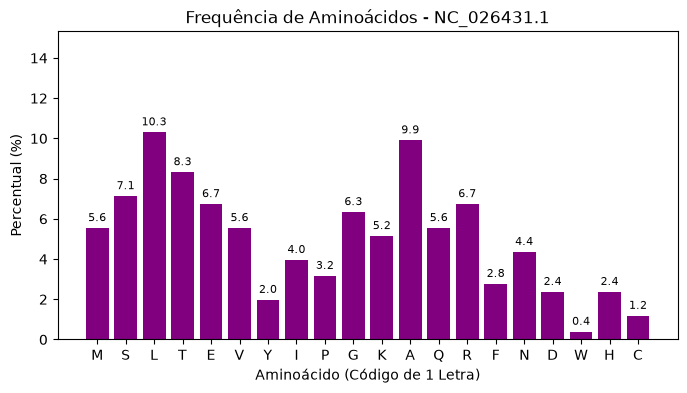

Accession: NC_007373.1
Proteína Traduzida (Primeiros 30 aa): MERIKELRNLMSQSRTREILTKTTVDHMAI...
Mais frequente: V (8.4%) | Menos frequente: C (0.7%)
--------------------------------------------------


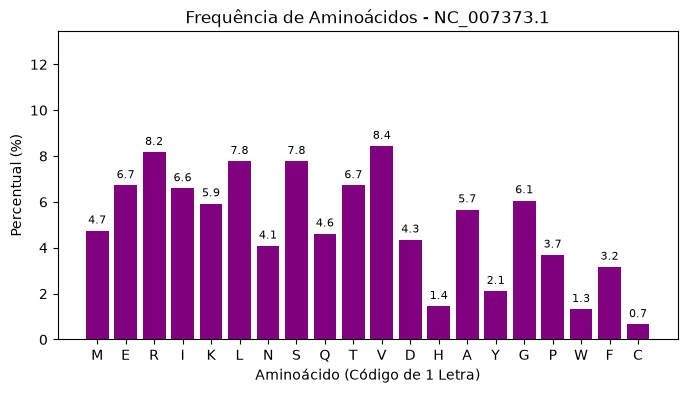

Accession: CY121659.1
Proteína Traduzida (Primeiros 30 aa): MASQGTKRSYEQMETDGERQNATEIRASVG...
Mais frequente: R (9.8%) | Menos frequente: C (1.2%)
--------------------------------------------------


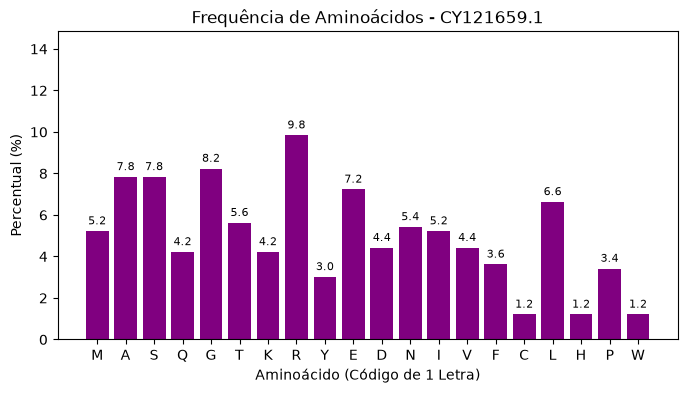

Accession: CY018104.1
Proteína Traduzida (Primeiros 30 aa): MSNMDIDGINTGTIDKTPEEITSGTSGTTR...
Mais frequente: K (8.8%) | Menos frequente: W (0.2%)
--------------------------------------------------


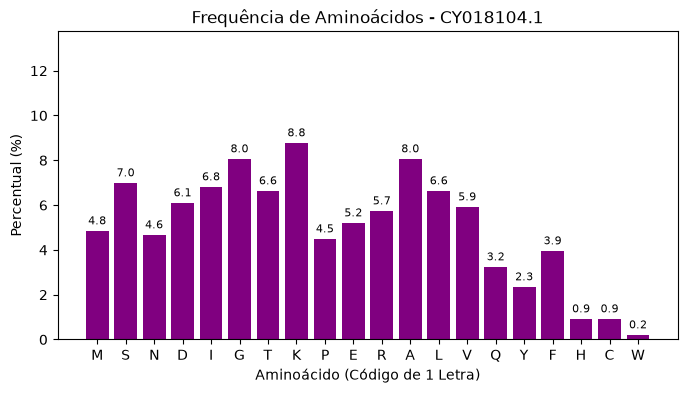

Accession: CY006241.1
Proteína Traduzida (Primeiros 30 aa): MDVNPTLLFLKVSAQNAISTTFPYTGDPPY...
Mais frequente: T (7.9%) | Menos frequente: W (1.2%)
--------------------------------------------------


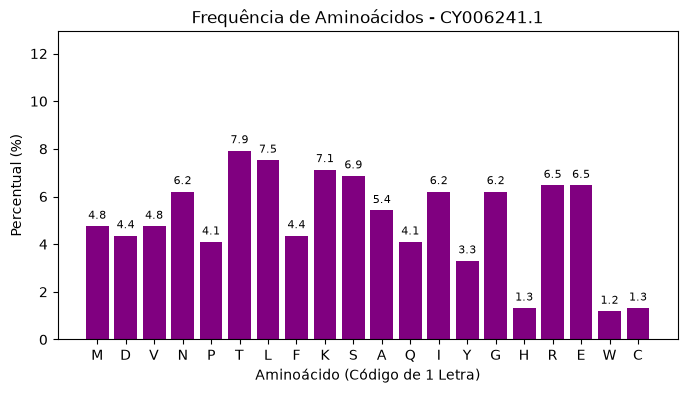

In [35]:
print("Resultados da Tradução Proteica e Frequências:\n")

for accession, seq in sequences_d2.items():
    protein = translate(seq)
    
    if not protein:
        print(f"[{accession}] Nenhum códon de início (ATG) encontrado.")
        continue
        
    freqs = aa_frequency(protein)
    
    # Encontrar o aminoácido mais e menos frequente
    max_aa = max(freqs.items(), key=lambda x: x[1][0])
    min_aa = min(freqs.items(), key=lambda x: x[1][0])
    
    print(f"Accession: {accession}")
    print(f"Proteína Traduzida (Primeiros 30 aa): {protein[:30]}...")
    print(f"Mais frequente: {max_aa[0]} ({max_aa[1][1]:.1f}%) | Menos frequente: {min_aa[0]} ({min_aa[1][1]:.1f}%)")
    print("-" * 50)
    
    # Gerar o Gráfico de Barras
    aa_labels = list(freqs.keys())
    aa_pcts = [val[1] for val in freqs.values()]
    
    plt.figure(figsize=(8, 4))
    bars = plt.bar(aa_labels, aa_pcts, color='purple')
    plt.title(f'Frequência de Aminoácidos - {accession}')
    plt.ylabel('Percentual (%)')
    plt.xlabel('Aminoácido (Código de 1 Letra)')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.2, f'{yval:.1f}', ha='center', va='bottom', fontsize=8)
        
    plt.ylim(0, max(aa_pcts) + 5)
    plt.show()

[cite_start]**Discussão Biológica:** *Espaço para o grupo preencher:* (A composição de aminoácidos difere entre as sequências? Existe relação com o conteúdo GC calculado na Tarefa D[cite: 219]? [cite_start]Verifiquem se as traduções geradas batem com o campo /translation no NCBI GenBank para atestar a precisão do código [cite: 218]).